In [1]:
import numpy as np
import pandas as pd
from caveclient import CAVEclient
from meshparty.skeleton import Skeleton
import os
import pickle
import matplotlib.pyplot as plt
import myelin_analysis
import plotly.express as px
from lookup_activity_by_pt_root_id import *

#for debugging
import importlib

In [ ]:
client = CAVEclient('minnie65_public')
client.version = 1507
cell_type_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')
coreg_df = client.materialize.query_table('coregistration_manual_v4')
digital_twin_coreg_df = client.materialize.query_table('digital_twin_properties_bcm_coreg_v4')
# myelin_info_df = pd.read_csv('myelin_info_df.csv')


In [149]:
myelin_info_df = myelin_analysis.create_myelin_info_df("segments_myelin_1507", cell_type_df)
myelin_info_df.to_csv('myelin_info_df.csv', index=False)

864691135739733140


/Users/charlesshvartsman/Library/Mobile Documents/com~apple~CloudDocs/Documents/phd_work/Sinha/myelin/MICrONS_Analysis/Myelin_Extract/myelin_analysis.py:60: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



864691136041000190
864691135938604804
864691136578982164
864691135209715577
864691135700409211
864691136176327430
864691136313301565
864691135417236410
864691135101521952
864691135562147041
864691135431089968
864691136195796182
864691135572385061
864691136196131542
864691135867009413
864691135782506832
864691134919144714
864691136725353725
864691135572346349
864691135993429185
864691136025329721
864691135699487522
864691135233242713
864691135725838763
864691136194355176
864691136134678667
864691135778465376
864691135778331232
864691135849401950
864691135430186032
864691136309871706
864691135356753871
864691135782265936
864691135875121038
864691135915343462
864691135258083503
864691135928938196
864691135105897037
864691134990291066
864691136991390869
864691136137834877
864691136927176778
864691136311213914
864691136137794941
864691135719761713
864691135274038801
864691136389679223
864691136620069517
864691135688446944
864691135685661367
864691135498997267
864691136392254847
864691135256

In [ ]:
''' A little thinking:
What is our goal? We've got a glimpse of Direction Selectivity Index correlating with myelination.
Let's try a bunch of activity analyses and see if we can find more correlations.
'''

In [4]:
# Get pt_root_ids of interest.
directory_segs_myelin = 'segments_myelin_1507/'
pt_root_ids = []
for filename in os.listdir(directory_segs_myelin):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        pt_root_ids.append(pt_root_id)

activity_df = lookup_activity_by_pt_root_ids(pt_root_ids, coreg_df, "microns_activity/", True)

Found 390 matches for 443 pt_root_ids
  - Spanning 6 sessions
  - Spanning 16 scans
Processing scan_4_7_coreg.zip (46 units to extract)...
Processing scan_5_3_coreg.zip (12 units to extract)...
Processing scan_5_6_coreg.zip (30 units to extract)...
Processing scan_5_7_coreg.zip (16 units to extract)...
Processing scan_6_2_coreg.zip (18 units to extract)...
Processing scan_6_4_coreg.zip (31 units to extract)...
Processing scan_6_6_coreg.zip (24 units to extract)...
Processing scan_6_7_coreg.zip (20 units to extract)...
Processing scan_7_3_coreg.zip (16 units to extract)...
Processing scan_7_4_coreg.zip (27 units to extract)...
Processing scan_7_5_coreg.zip (36 units to extract)...
Processing scan_8_5_coreg.zip (57 units to extract)...
Processing scan_8_7_coreg.zip (1 units to extract)...
Processing scan_9_3_coreg.zip (10 units to extract)...
Processing scan_9_4_coreg.zip (34 units to extract)...
Processing scan_9_6_coreg.zip (12 units to extract)...

Extracted 389 units


In [5]:
activity_df.head()

,pt_root_id,unit_id,session,scan_idx,nframes,fps,spike_trace,calcium_trace
0,864691135429763120,2629,4,7,40000.0,6.3009,"[3.4809585e-07, 4.3540356e-07, 4.1618136e-07, ...","[81.131874, 44.909832, 190.05423, 229.76253, 1..."
1,864691136330407914,3177,4,7,40000.0,6.3009,"[7.241326e-08, 9.593168e-08, 1.1101842e-07, 1....","[138.64484, 175.14969, 114.27973, 68.20031, 19..."
2,864691135455123562,3304,4,7,40000.0,6.3009,"[3.0807107e-07, 2.8583023e-07, 3.8244167e-07, ...","[20.761637, -47.55179, -17.663445, -5.873332, ..."
3,864691135462420637,5495,4,7,40000.0,6.3009,"[7.22321e-08, 8.492295e-08, 1.07250706e-07, 7....","[25.87128, 19.772907, 49.26478, 51.94985, -18...."
4,864691135503182685,7981,4,7,40000.0,6.3009,"[4.3815302e-09, 2.491057e-09, 1.7034554e-09, 1...","[78.78576, 83.77005, -6.8678136, 23.353504, 60..."


In [6]:
#Create z_scored_trace column
activity_df['z_scored_trace'] = activity_df['calcium_trace'].apply(lambda x: (x - np.mean(x)) / np.std(x))
activity_df.head()

,pt_root_id,unit_id,session,scan_idx,nframes,fps,spike_trace,calcium_trace,z_scored_trace
0,864691135429763120,2629,4,7,40000.0,6.3009,"[3.4809585e-07, 4.3540356e-07, 4.1618136e-07, ...","[81.131874, 44.909832, 190.05423, 229.76253, 1...","[-0.121810496, -0.24729033, 0.2555166, 0.39307..."
1,864691136330407914,3177,4,7,40000.0,6.3009,"[7.241326e-08, 9.593168e-08, 1.1101842e-07, 1....","[138.64484, 175.14969, 114.27973, 68.20031, 19...","[0.18839838, 0.3295999, 0.09415365, -0.0840824..."
2,864691135455123562,3304,4,7,40000.0,6.3009,"[3.0807107e-07, 2.8583023e-07, 3.8244167e-07, ...","[20.761637, -47.55179, -17.663445, -5.873332, ...","[-0.43906832, -0.76221925, -0.62083495, -0.565..."
3,864691135462420637,5495,4,7,40000.0,6.3009,"[7.22321e-08, 8.492295e-08, 1.07250706e-07, 7....","[25.87128, 19.772907, 49.26478, 51.94985, -18....","[-0.13750781, -0.31237116, 0.533272, 0.6102631..."
4,864691135503182685,7981,4,7,40000.0,6.3009,"[4.3815302e-09, 2.491057e-09, 1.7034554e-09, 1...","[78.78576, 83.77005, -6.8678136, 23.353504, 60...","[-0.001063905, 0.048405856, -0.85118717, -0.55..."


In [145]:
#add sum_calcium_trace column
activity_df['sum_calcium_trace'] = activity_df['calcium_trace'].apply(lambda x: np.sum(x))

myelin_and_activity_df = pd.merge(myelin_info_df, activity_df, on='pt_root_id', how='inner')


In [90]:
#BASELINE SUBTRACT: Create z_baseline_subtract column. Subtract mean of last 1000 frames from each trace. Divide by std of last 1000 frames.
activity_df['z_baseline_subtract'] = activity_df['calcium_trace'].apply(lambda x: (x - np.mean(x[-1000:])) / np.std(x[-1000:]))
activity_df['high_zbase_sub_value'] = activity_df['z_baseline_subtract'].apply(lambda x: np.sum(x > 3))
activity_df.head()




,pt_root_id,unit_id,session,scan_idx,nframes,fps,spike_trace,calcium_trace,z_scored_trace,high_zscore_value,z_baseline_subtract,high_zbase_sub_value
0,864691135429763120,2629,4,7,40000.0,6.3009,"[3.4809585e-07, 4.3540356e-07, 4.1618136e-07, ...","[81.131874, 44.909832, 190.05423, 229.76253, 1...","[-0.121810496, -0.24729033, 0.2555166, 0.39307...",2098,"[2.7642002, 1.7507004, 5.811869, 6.9229155, 3....",11587
1,864691136330407914,3177,4,7,40000.0,6.3009,"[7.241326e-08, 9.593168e-08, 1.1101842e-07, 1....","[138.64484, 175.14969, 114.27973, 68.20031, 19...","[0.18839838, 0.3295999, 0.09415365, -0.0840824...",1807,"[5.3325186, 6.232142, 4.732066, 3.5964873, 6.8...",17308
2,864691135455123562,3304,4,7,40000.0,6.3009,"[3.0807107e-07, 2.8583023e-07, 3.8244167e-07, ...","[20.761637, -47.55179, -17.663445, -5.873332, ...","[-0.43906832, -0.76221925, -0.62083495, -0.565...",1969,"[0.7228302, -1.5195074, -0.5384447, -0.1514429...",13560
3,864691135462420637,5495,4,7,40000.0,6.3009,"[7.22321e-08, 8.492295e-08, 1.07250706e-07, 7....","[25.87128, 19.772907, 49.26478, 51.94985, -18....","[-0.13750781, -0.31237116, 0.533272, 0.6102631...",1407,"[-0.22534569, -0.53029877, 0.9444613, 1.07873,...",1954
4,864691135503182685,7981,4,7,40000.0,6.3009,"[4.3815302e-09, 2.491057e-09, 1.7034554e-09, 1...","[78.78576, 83.77005, -6.8678136, 23.353504, 60...","[-0.001063905, 0.048405856, -0.85118717, -0.55...",1829,"[4.7624125, 5.0338545, 0.09776464, 1.7436014, ...",21319


In [97]:
#1.1 For each z_scored_trace, calculate amount of time above 10 std, store in column "high_zscore_value"ArithmeticError
activity_df['high_zscore_value'] = activity_df['z_scored_trace'].apply(lambda x: np.sum(x > 8))
activity_df.head()

,pt_root_id,unit_id,session,scan_idx,nframes,fps,spike_trace,calcium_trace,z_scored_trace,high_zscore_value,z_baseline_subtract,high_zbase_sub_value
0,864691135429763120,2629,4,7,40000.0,6.3009,"[3.4809585e-07, 4.3540356e-07, 4.1618136e-07, ...","[81.131874, 44.909832, 190.05423, 229.76253, 1...","[-0.121810496, -0.24729033, 0.2555166, 0.39307...",0,"[2.7642002, 1.7507004, 5.811869, 6.9229155, 3....",11587
1,864691136330407914,3177,4,7,40000.0,6.3009,"[7.241326e-08, 9.593168e-08, 1.1101842e-07, 1....","[138.64484, 175.14969, 114.27973, 68.20031, 19...","[0.18839838, 0.3295999, 0.09415365, -0.0840824...",9,"[5.3325186, 6.232142, 4.732066, 3.5964873, 6.8...",17308
2,864691135455123562,3304,4,7,40000.0,6.3009,"[3.0807107e-07, 2.8583023e-07, 3.8244167e-07, ...","[20.761637, -47.55179, -17.663445, -5.873332, ...","[-0.43906832, -0.76221925, -0.62083495, -0.565...",16,"[0.7228302, -1.5195074, -0.5384447, -0.1514429...",13560
3,864691135462420637,5495,4,7,40000.0,6.3009,"[7.22321e-08, 8.492295e-08, 1.07250706e-07, 7....","[25.87128, 19.772907, 49.26478, 51.94985, -18....","[-0.13750781, -0.31237116, 0.533272, 0.6102631...",5,"[-0.22534569, -0.53029877, 0.9444613, 1.07873,...",1954
4,864691135503182685,7981,4,7,40000.0,6.3009,"[4.3815302e-09, 2.491057e-09, 1.7034554e-09, 1...","[78.78576, 83.77005, -6.8678136, 23.353504, 60...","[-0.001063905, 0.048405856, -0.85118717, -0.55...",0,"[4.7624125, 5.0338545, 0.09776464, 1.7436014, ...",21319


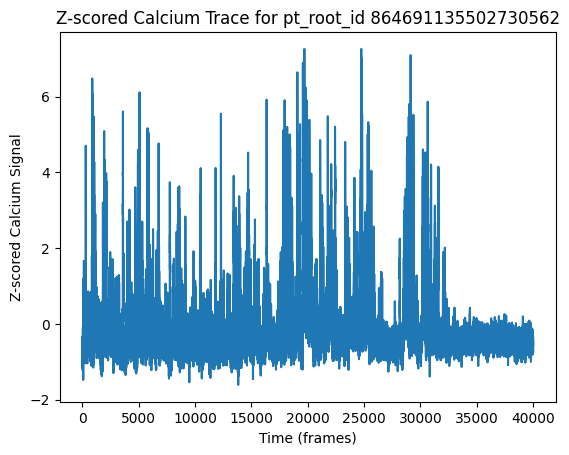

In [98]:
#plot zscored trace of a random pt_root_id
random_pt_root_id = np.random.choice(activity_df['pt_root_id'].values)
random_trace = activity_df[activity_df['pt_root_id'] == random_pt_root_id]['z_scored_trace'].values[0]
plt.plot(random_trace)
plt.title(f'Z-scored Calcium Trace for pt_root_id {random_pt_root_id}')
plt.xlabel('Time (frames)')
plt.ylabel('Z-scored Calcium Signal')
plt.show()

In [99]:
#1.2 For myelin_info_df, add column "high_zscore_value" by merging with activity_df on pt_root_id. If multiple values exist, take the mean.
myelin_and_activity_df = myelin_info_df.merge(activity_df[['pt_root_id', 'high_zbase_sub_value']], on='pt_root_id', how='left')
myelin_and_activity_df.head()

,pt_root_id,total_myelin_length,cell_type,number_of_segments,high_zbase_sub_value
0,864691135739733140,221.03,4P,29,3341.0
1,864691136041000190,0.00,6P-IT,63,NaN
2,864691135938604804,279.49,23P,104,1300.0
3,864691136578982164,0.00,4P,69,9420.0
4,864691135209715577,0.00,6P-IT,9,NaN


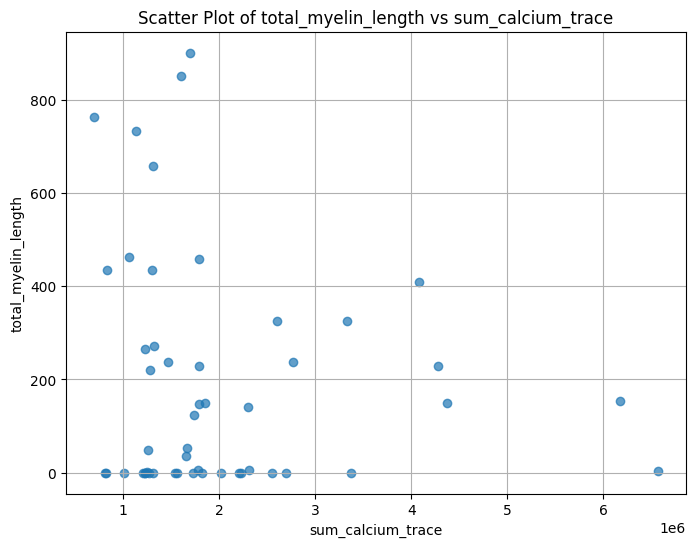

Pearson r: -0.12229369374882995, p-value: 0.39752078290217574


In [148]:
#Scatter plot of "high_zscore_value" vs "total_myelin_length", ignoring nans
#remove high_zscore_value nans

filtered_df = myelin_and_activity_df.copy()

# filter for cell_type == 23P
filtered_df = filtered_df[filtered_df['cell_type'] == '4P']

filtered_df = filtered_df[~filtered_df['sum_calcium_trace'].isna()]

var_x = "sum_calcium_trace"
var_y = "total_myelin_length"

plt.figure(figsize=(8,6))
plt.scatter(filtered_df[var_x], filtered_df[var_y], alpha=0.7)
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.title(f'Scatter Plot of {var_y} vs {var_x}')
plt.grid(True)
plt.show()

#get correlation coeff and p value between var_x and var_y
from scipy.stats import pearsonr, spearmanr
corr_coeff, p_value = pearsonr(filtered_df[var_x], filtered_df[var_y])
print(f"Pearson r: {corr_coeff}, p-value: {p_value}")

# Are more myelinated neurons more similar in functional properties to their post-synaptic partners?

In [106]:
#0.1 Start by getting myelin info, and 

#From before, we already have meylin_info_df and digital_twin_coreg_df

In [105]:
#0.2 Load all synapses for these neurons.
synapse_delay_list = []
for filename in os.listdir('synapse_len_delay_1507'):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        if pt_root_id in activity_df['pt_root_id'].tolist():
            with open(os.path.join('synapse_len_delay_1507', filename), 'rb') as f:
                syn_df = pickle.load(f)
                synapse_delay_list.append(syn_df)
            synapse_delay_df = pd.concat(synapse_delay_list, ignore_index=True)

In [136]:
#For each pt_root_id in myelin_info_df, get its pref_dir in digital_twin_coreg_df
#Then go through synapse_delay_df for pre_pt_root_id == pt_root_id, and get pref_dir of post_pt_root_id

#merge pref_dir, DSI from digital_twin_coreg_df into myelin_info_df
merged_df = myelin_info_df.merge(digital_twin_coreg_df[['pt_root_id', 'pref_dir', 'DSI']], on='pt_root_id', how='left')

#collect pref_dir for all postsynaptic partners
count = 0
for index, row in merged_df.iterrows():
    if count % 20 == 0:
        print(f"Processing {count}/{merged_df.shape[0]}")
    count += 1
    pt_root_id = row['pt_root_id']
    if row['DSI'] < .5:
        continue
    pref_dir = row['pref_dir']
    #get all post_pt_root_id where pre_pt_root_id == pt_root_id
    post_syn_df = synapse_delay_df[synapse_delay_df['pre_pt_root_id'] == pt_root_id]
    post_pt_root_ids = post_syn_df['post_pt_root_id']
    post_pref_dirs = []
    for post_pt_root_id in post_pt_root_ids:
        post_pref_dir = digital_twin_coreg_df[digital_twin_coreg_df['pt_root_id'] == post_pt_root_id]['pref_dir'].values
        post_DSI = digital_twin_coreg_df[digital_twin_coreg_df['pt_root_id'] == post_pt_root_id]['DSI'].values
        if len(post_pref_dir) > 0:
            if post_DSI[0] >= .5:
                post_pref_dirs.append(post_pref_dir[0])
    #Subtract pref_dir from each post_pref_dir, take modulo 360. Get mean of these values.
    if len(post_pref_dirs) > 0:
        angle_diffs = [(abs(pref_dir - post_pref_dir) % 360) for post_pref_dir in post_pref_dirs]
        mean_angle_diff = np.mean(angle_diffs)
    else:
        mean_angle_diff = np.nan
    merged_df.at[index, 'mean_postsyn_pref_dir_diff'] = mean_angle_diff





Processing 0/545
Processing 20/545
Processing 40/545
Processing 60/545
Processing 80/545
Processing 100/545
Processing 120/545
Processing 140/545
Processing 160/545
Processing 180/545
Processing 200/545
Processing 220/545
Processing 240/545
Processing 260/545
Processing 280/545
Processing 300/545
Processing 320/545
Processing 340/545
Processing 360/545
Processing 380/545
Processing 400/545
Processing 420/545
Processing 440/545
Processing 460/545
Processing 480/545
Processing 500/545
Processing 520/545
Processing 540/545


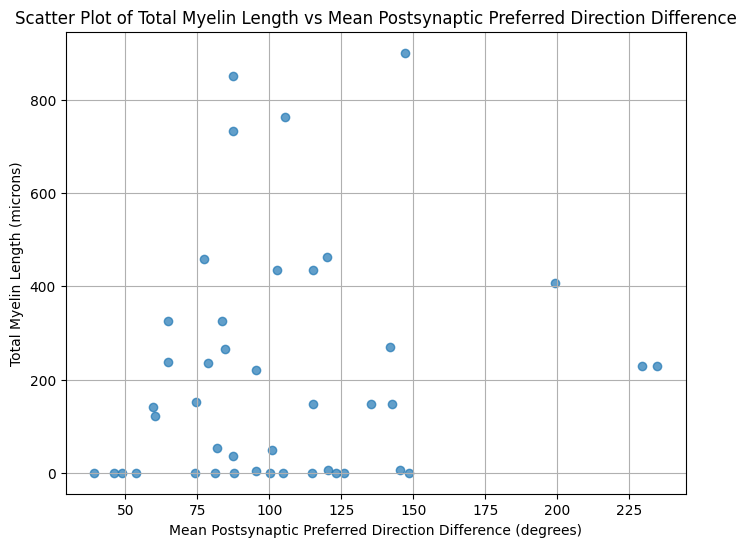

Pearson r: 0.15572256544209412, p-value: 0.31869120959008773


In [138]:
#1.1 Make a scatter plot of mean_postsyn_pref_dir_diff vs total_myelin_length, ignoring nans
#remove mean_postsyn_pref_dir_diff nans
filtered_df = merged_df[~merged_df['mean_postsyn_pref_dir_diff'].isna()]

#Filter for cell_type = 23P
cell_types_to_include = ['4P']
pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
filtered_df = filtered_df[filtered_df['pt_root_id'].isin(pt_root_ids_to_include)]

plt.figure(figsize=(8,6))
plt.scatter(filtered_df['mean_postsyn_pref_dir_diff'], filtered_df['total_myelin_length'], alpha=0.7)
plt.xlabel('Mean Postsynaptic Preferred Direction Difference (degrees)')
plt.ylabel('Total Myelin Length (microns)')
plt.title('Scatter Plot of Total Myelin Length vs Mean Postsynaptic Preferred Direction Difference')
plt.grid(True)
plt.show()

#1.2 Get correlation coeff and p value between mean_postsyn_pref_dir_diff and total_myelin_length
from scipy.stats import pearsonr
corr_coeff, p_value = pearsonr(filtered_df['mean_postsyn_pref_dir_diff'], filtered_df['total_myelin_length'])
print(f"Pearson r: {corr_coeff}, p-value: {p_value}")


In [140]:
#1.5 Try seeing if DSI of postsynapses correlates with myelination


#merge pref_dir, DSI from digital_twin_coreg_df into myelin_info_df
merged_df = myelin_info_df.merge(digital_twin_coreg_df[['pt_root_id', 'pref_dir', 'DSI']], on='pt_root_id', how='left')

#collect pref_dir for all postsynaptic partners
count = 0
for index, row in merged_df.iterrows():
    if count % 20 == 0:
        print(f"Processing {count}/{merged_df.shape[0]}")
    count += 1
    pt_root_id = row['pt_root_id']
    DSI = row['DSI']
    #get all post_pt_root_id where pre_pt_root_id == pt_root_id
    post_syn_df = synapse_delay_df[synapse_delay_df['pre_pt_root_id'] == pt_root_id]
    post_pt_root_ids = post_syn_df['post_pt_root_id']
    post_DSIs = []
    for post_pt_root_id in post_pt_root_ids:
        post_DSI = digital_twin_coreg_df[digital_twin_coreg_df['pt_root_id'] == post_pt_root_id]['DSI'].values
        if len(post_DSI) > 0:
            post_DSIs.append(post_DSI[0])
    #Subtract pref_dir from each post_pref_dir, take modulo 360. Get mean of these values.
    if len(post_DSIs) > 0:
        mean_post_DSI = np.mean(post_DSIs)
    else:
        mean_post_DSI = np.nan
    merged_df.at[index, 'mean_post_DSI'] = mean_post_DSI





Processing 0/545
Processing 20/545
Processing 40/545
Processing 60/545
Processing 80/545
Processing 100/545
Processing 120/545
Processing 140/545
Processing 160/545
Processing 180/545
Processing 200/545
Processing 220/545
Processing 240/545
Processing 260/545
Processing 280/545
Processing 300/545
Processing 320/545
Processing 340/545
Processing 360/545
Processing 380/545
Processing 400/545
Processing 420/545
Processing 440/545
Processing 460/545
Processing 480/545
Processing 500/545
Processing 520/545
Processing 540/545


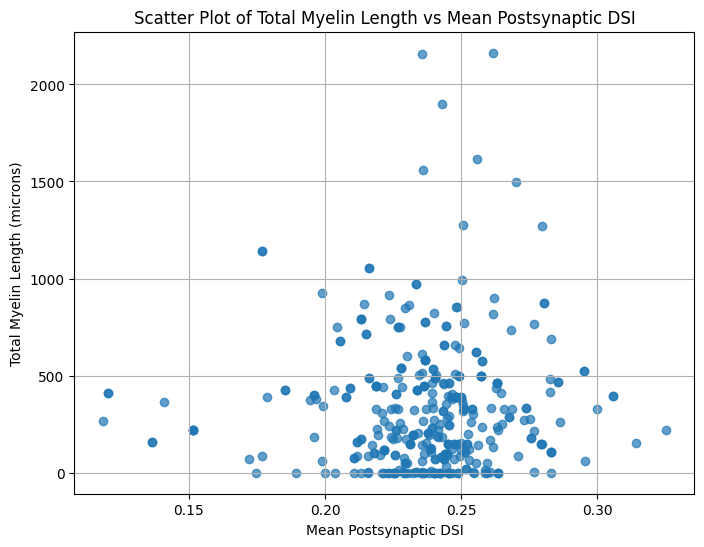

Pearson r: 0.02686393219813755, p-value: 0.6099439662103799


In [143]:
#1.6 Make a scatter plot of post_DSI vs total_myelin_length, ignoring nans
#remove mean_postsyn_pref_dir_diff nans
filtered_df = merged_df[~merged_df['mean_post_DSI'].isna()]

# #Filter for cell_type = 23P
# cell_types_to_include = ['4P']
# pt_root_ids_to_include = cell_type_df[cell_type_df['cell_type'].isin(cell_types_to_include)]['pt_root_id'].tolist()
# filtered_df = filtered_df[filtered_df['pt_root_id'].isin(pt_root_ids_to_include)]

plt.figure(figsize=(8,6))
plt.scatter(filtered_df['mean_post_DSI'], filtered_df['total_myelin_length'], alpha=0.7)
plt.xlabel('Mean Postsynaptic DSI')
plt.ylabel('Total Myelin Length (microns)')
plt.title('Scatter Plot of Total Myelin Length vs Mean Postsynaptic DSI')
plt.grid(True)
plt.show()

#1.7 Get correlation coeff and p value between mean_post_DSI and total_myelin_length
from scipy.stats import pearsonr
corr_coeff, p_value = pearsonr(filtered_df['mean_post_DSI'], filtered_df['total_myelin_length'])
print(f"Pearson r: {corr_coeff}, p-value: {p_value}")
